<a href="https://colab.research.google.com/github/BonBergado/nlp-phishing-classifier/blob/main/phishing_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎣 NLP Phishing Email Classifier
**End-to-end pipeline: data → preprocessing → features → model → evaluation → prediction**

Uses the public SMS Spam Collection dataset as a stand-in (same binary classification task).
Swap in your own email dataset at Cell 2 to go full phishing-specific.

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install -q scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

In [2]:
# ── Cell 2: Load dataset ───────────────────────────────────────────────────────
import pandas as pd

# --- Option A: Public SMS Spam dataset (auto-downloads) ---
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])
df['label'] = df['label'].map({'spam': 1, 'ham': 0})   # 1 = phishing/spam, 0 = legit

# --- Option B: Your own CSV (uncomment and upload via Colab Files panel) ---
# from google.colab import files
# uploaded = files.upload()   # upload a CSV with columns: 'text', 'label'
# df = pd.read_csv(list(uploaded.keys())[0])

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
df.head()

Dataset shape: (5572, 2)

Class distribution:
label
0    4825
1     747
Name: count, dtype: int64


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# ── Cell 3: Text preprocessing ────────────────────────────────────────────────
import re

def preprocess(text):
    """
    Clean raw email/SMS text while preserving phishing signals.
    - URLs and email addresses are replaced with tokens (their presence is a signal)
    - Urgency phrases, numbers, and structure are kept
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' <URL> ', text)   # keep URL presence
    text = re.sub(r'\S+@\S+', ' <EMAIL> ', text)           # keep email presence
    text = re.sub(r'\b\d{10,}\b', ' <PHONE> ', text)       # phone numbers
    text = re.sub(r'[^\w\s<>]', ' ', text)                 # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()               # collapse whitespace
    return text

df['clean_text'] = df['text'].apply(preprocess)

print("Original: ", df['text'].iloc[0])
print("Cleaned:  ", df['clean_text'].iloc[0])

Original:  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned:   go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [4]:
# ── Cell 4: Hand-crafted phishing features ────────────────────────────────────
import numpy as np

URGENCY_WORDS = r'urgent|immediately|verify|suspend|click|confirm|account|winner|prize|free|limited|act now'

def extract_features(text):
    """Domain-specific features that NLP alone may miss."""
    return {
        'url_count'        : len(re.findall(r'<URL>', text)),
        'email_count'      : len(re.findall(r'<EMAIL>', text)),
        'phone_count'      : len(re.findall(r'<PHONE>', text)),
        'urgency_hits'     : len(re.findall(URGENCY_WORDS, text)),
        'exclamation_count': text.count('!'),
        'caps_ratio'       : sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'text_length'      : len(text),
        'word_count'       : len(text.split()),
        'digit_ratio'      : sum(1 for c in text if c.isdigit()) / max(len(text), 1),
    }

feature_df = df['text'].apply(extract_features).apply(pd.Series)
print(feature_df.head())

   url_count  email_count  phone_count  urgency_hits  exclamation_count  \
0        0.0          0.0          0.0           0.0                0.0   
1        0.0          0.0          0.0           0.0                0.0   
2        0.0          0.0          0.0           0.0                0.0   
3        0.0          0.0          0.0           0.0                0.0   
4        0.0          0.0          0.0           0.0                0.0   

   caps_ratio  text_length  word_count  digit_ratio  
0    0.027027        111.0        20.0      0.00000  
1    0.068966         29.0         6.0      0.00000  
2    0.064516        155.0        28.0      0.16129  
3    0.040816         49.0        11.0      0.00000  
4    0.032787         61.0        13.0      0.00000  


In [5]:
# ── Cell 5: Build the full feature matrix ─────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

# TF-IDF on cleaned text (unigrams + bigrams)
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True,       # log normalization
    min_df=2
)
X_tfidf = tfidf.fit_transform(df['clean_text'])

# Combine TF-IDF with hand-crafted features
X_hand = csr_matrix(feature_df.values)
X = hstack([X_tfidf, X_hand])   # final feature matrix
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (5572, 14754)


In [6]:
# ── Cell 6: Train / test split ────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # preserve class ratio in both splits
    random_state=42
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train phishing rate: {y_train.mean():.2%}")

Train size: 4457  |  Test size: 1115
Train phishing rate: 13.42%


In [7]:
# ── Cell 7: Train model ───────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',  # handles imbalanced classes automatically
    max_iter=1000,
    C=1.0,
    solver='lbfgs'
)
model.fit(X_train, y_train)
print("✅ Model trained.")

✅ Model trained.


Classification Report
              precision    recall  f1-score   support

       Legit       0.99      0.98      0.98       966
    Phishing       0.86      0.92      0.89       149

    accuracy                           0.97      1115
   macro avg       0.92      0.95      0.94      1115
weighted avg       0.97      0.97      0.97      1115

ROC-AUC: 0.9919


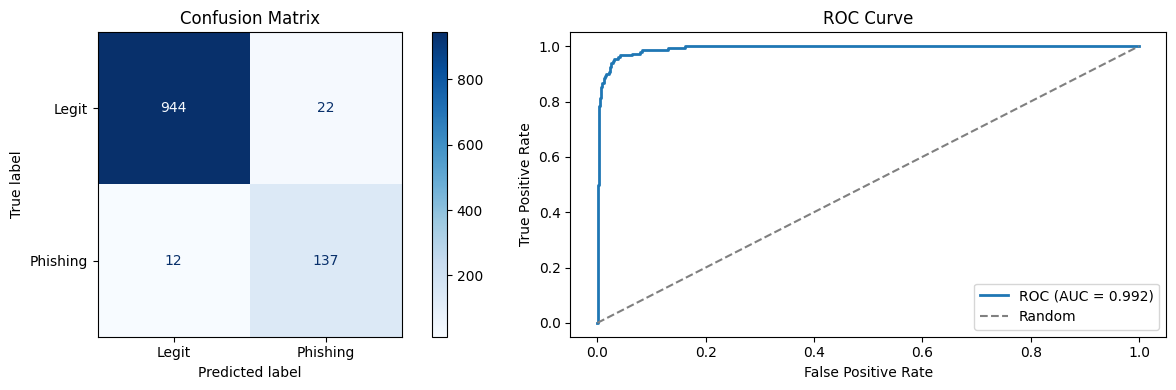

In [8]:
# ── Cell 8: Evaluate ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]
roc_auc     = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Legit', 'Phishing']))
print(f"ROC-AUC: {roc_auc:.4f}")

# ── Confusion matrix ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Legit', 'Phishing'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ── ROC curve ──
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

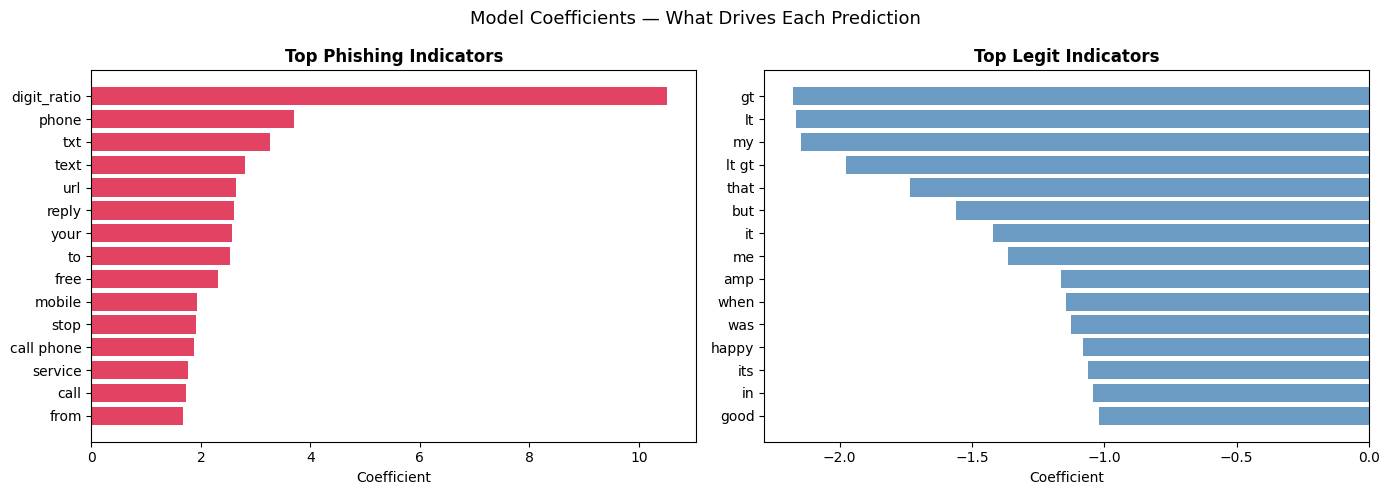

In [9]:
# ── Cell 9: Top predictive words ──────────────────────────────────────────────
import matplotlib.pyplot as plt

# Get TF-IDF feature names (hand-crafted features are appended at the end)
feature_names = (
    tfidf.get_feature_names_out().tolist()
    + feature_df.columns.tolist()
)

coef = model.coef_[0]
top_n = 15

top_phishing = np.argsort(coef)[-top_n:][::-1]
top_legit    = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, indices, title, color in [
    (axes[0], top_phishing, 'Top Phishing Indicators', 'crimson'),
    (axes[1], top_legit,    'Top Legit Indicators',    'steelblue')
]:
    words = [feature_names[i] for i in indices]
    vals  = [coef[i] for i in indices]
    ax.barh(words[::-1], vals[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle('Model Coefficients — What Drives Each Prediction', fontsize=13)
plt.tight_layout()
plt.show()

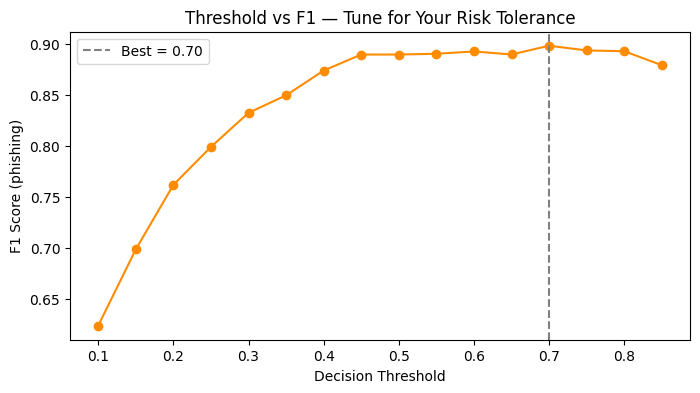

Best threshold: 0.70  →  F1: 0.8982


In [10]:
# ── Cell 10: Threshold tuning ─────────────────────────────────────────────────
# Default threshold is 0.5. Lower it to catch MORE phishing (at cost of more false alarms).
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, marker='o', color='darkorange')
plt.axvline(best_thresh, linestyle='--', color='gray', label=f'Best = {best_thresh:.2f}')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score (phishing)')
plt.title('Threshold vs F1 — Tune for Your Risk Tolerance')
plt.legend()
plt.show()

print(f"Best threshold: {best_thresh:.2f}  →  F1: {max(f1_scores):.4f}")

In [11]:
# ── Cell 11: Predict on new text ──────────────────────────────────────────────
THRESHOLD = best_thresh   # use tuned threshold, or set manually e.g. 0.4

def predict_email(text, threshold=THRESHOLD):
    """
    Classify a single email/message as Phishing or Legit.
    Returns label, confidence, and top contributing words.
    """
    cleaned = preprocess(text)
    X_t     = tfidf.transform([cleaned])
    X_h     = csr_matrix(pd.DataFrame([extract_features(text)]).values)
    X_in    = hstack([X_t, X_h])

    prob    = model.predict_proba(X_in)[0][1]
    label   = 'PHISHING 🚨' if prob >= threshold else 'LEGIT ✅'

    return {'label': label, 'phishing_probability': f'{prob:.2%}'}


# ── Try it out ──
examples = [
    "URGENT: Your account has been suspended. Click here immediately to verify: http://secure-login.phish.com",
    "Hey, are we still on for lunch on Thursday? Let me know!",
    "Congratulations! You've won a FREE iPhone. Claim your prize now before it expires!",
    "Please find the Q3 report attached. Let me know if you have any questions.",
]

for msg in examples:
    result = predict_email(msg)
    print(f"[{result['label']}] ({result['phishing_probability']})")
    print(f"  → {msg[:80]}...\n")

[PHISHING 🚨] (99.48%)
  → URGENT: Your account has been suspended. Click here immediately to verify: http:...

[LEGIT ✅] (3.79%)
  → Hey, are we still on for lunch on Thursday? Let me know!...

[PHISHING 🚨] (84.73%)
  → Congratulations! You've won a FREE iPhone. Claim your prize now before it expire...

[LEGIT ✅] (8.62%)
  → Please find the Q3 report attached. Let me know if you have any questions....



## Next Steps
| Goal | What to do |
|---|---|
| Better accuracy | Swap LR for `RandomForestClassifier` or fine-tune `distilbert-base-uncased` |
| Real email data | Parse `.eml` files with Python's `email` module, feed `subject + body` as text |
| Explainability | Install `shap` and run `shap.LinearExplainer` on the model |
| Deployment | Wrap `predict_email()` in a FastAPI endpoint |
| Adversarial robustness | Test with obfuscated text: `fr3e`, `veri fy`, unicode lookalikes |